# Predicting the thermal Sunyaev–Zel'dovich effect — from one equation to a real measurement

## A deep-dive companion to N10, ending with a hands-on reproduction of an ACT × BOSS result

**Module 3 — Multi-wavelength large-scale-structure cosmology (PhD onboarding).**

The thermal Sunyaev–Zel'dovich (tSZ) effect is the tiny spectral distortion imprinted on the
cosmic microwave background (CMB) when its photons scatter off the hot electrons of the ionised gas
that fills dark-matter halos. It is one of the four observables combined in the thesis (galaxies,
weak lensing, X-rays, **SZ**) and is measured by *Planck*, SPT and ACT.

This notebook has two parts:

* **Part 1 — the prediction.** We rebuild the tSZ observable *from scratch*, adding, for **every**
  equation, (i) a short derivation you can follow with third-year physics, (ii) a boxed
  **order-of-magnitude estimate**, (iii) the meaning of every symbol, and (iv) primary references
  with working links.
* **Part 2 — the confrontation with data.** We review recent tSZ measurements around clusters,
  groups and galaxies, then reproduce one whose model ingredients are **public** (Schaan &
  Amodeo 2021, ACT × BOSS CMASS). We first try the *simplest* model of Part 1 — and watch it fail —
  then build the *full forward model* (realistic pressure profile → line-of-sight projection →
  telescope-beam smearing → the actual filter used on the sky) that reproduces the measurement.

**Key tools:** `numpy`, `scipy`, `matplotlib`, `astropy` (constants, units, cosmology) and a little
`jax` for automatic differentiation. Everything runs in the `mlco` environment.

### Learning objectives

By the end you should be able to:

1. **Derive** the Compton-$y$ parameter from the physics of inverse-Compton scattering, and explain
   why it measures the *integrated electron pressure*.
2. **Explain and plot** the universal tSZ spectral distortion $f(x)$, and locate the $\sim$217 GHz
   frequency where the effect vanishes.
3. **Turn a halo mass into a prediction**: use a generalised-NFW (GNFW) pressure profile to compute
   a $y(\theta)$ map, and estimate the integrated signal $Y$ and its steep sensitivity to $\sigma_8$.
4. **Read the recent literature** on tSZ measurements around clusters, groups and galaxies.
5. **Reproduce a real measurement**: understand *why* the textbook model of Part 1 cannot match the
   ACT × CMASS data, and assemble the four extra ingredients (realistic profile, projection, beam,
   compensated-aperture filter) that make the full forward model work.

### How to read this notebook

* 📦 **Order-of-magnitude boxes** plug real numbers into each equation. Getting the *power of ten*
  right — before trusting any code — is the single most useful habit in astrophysics.
* 🎓 **Concept notes** unpack any idea that goes beyond a standard third-year (L3) physics course
  (optical depth, the Abel projection integral, angular-diameter distance, automatic
  differentiation, convolution, …). Nothing is assumed beyond mechanics, E&M, thermodynamics and
  first-year calculus.
* Every boxed equation is followed by the definition of **all** its symbols and at least one
  **reference** (§ *References* below). Links were checked and point to the arXiv preprint (open
  access) with the journal reference given in the text.

## References

**Foundational tSZ physics**
- Sunyaev & Zel'dovich (1972), *Comments Astrophys. Space Phys.* **4**, 173 — the original effect.
  [ADS:1972CoASP...4..173S](https://ui.adsabs.harvard.edu/abs/1972CoASP...4..173S)
- Carlstrom, Holder & Reese (2002), *ARA&A* **40**, 643 — the classic review.
  [arXiv:astro-ph/0208192](https://arxiv.org/abs/astro-ph/0208192)
- Itoh, Kohyama & Nozawa (1998), *ApJ* **502**, 7 — relativistic corrections to $f(x)$.
  [arXiv:astro-ph/9712289](https://arxiv.org/abs/astro-ph/9712289)
- Mroczkowski et al. (2019), *Space Sci. Rev.* **215**, 17 — modern SZ review.
  [arXiv:1811.02310](https://arxiv.org/abs/1811.02310)

**Pressure profiles**
- Nagai, Kravtsov & Vikhlinin (2007), *ApJ* **668**, 1 — the GNFW pressure form.
  [arXiv:astro-ph/0703661](https://arxiv.org/abs/astro-ph/0703661)
- Arnaud et al. (2010), *A&A* **517**, A92 — the "universal" pressure profile (REXCESS).
  [arXiv:0910.1234](https://arxiv.org/abs/0910.1234)
- Battaglia, Bond, Pfrommer & Sievers (2012), *ApJ* **758**, 75 — mass- and redshift-dependent
  GNFW pressure from simulations. [arXiv:1109.3711](https://arxiv.org/abs/1109.3711)

**Cosmology with the tSZ**
- Komatsu & Seljak (2002), *MNRAS* **336**, 1256 — tSZ power spectrum $\propto\sigma_8^{\,7\text{–}8}$.
  [arXiv:astro-ph/0205468](https://arxiv.org/abs/astro-ph/0205468)
- Planck Collaboration XXII (2016), *A&A* **594**, A22 — all-sky tSZ ($y$) map.
  [arXiv:1502.01596](https://arxiv.org/abs/1502.01596)

**Measurements around clusters / groups / galaxies (Part 2)**
- Schaan et al. (2021), *PRD* **103**, 063513 — ACT×CMASS stacked tSZ & kSZ (the measurement).
  [arXiv:2009.05557](https://arxiv.org/abs/2009.05557)
- Amodeo et al. (2021), *PRD* **103**, 063514 — gas thermodynamics modelling of the above.
  [arXiv:2009.05558](https://arxiv.org/abs/2009.05558)
- Vikram, Lidz & Jain (2017), *MNRAS* **467**, 2315 — SDSS groups × Planck $y$.
  [arXiv:1608.04160](https://arxiv.org/abs/1608.04160)
- Pratt & Bregman (2021), *ApJ* **920**, 24 — resolved SZ profiles of nearby groups.
  [arXiv:2107.04564](https://arxiv.org/abs/2107.04564)
- Meinke et al. (2021), *ApJ* **913**, 88 — tSZ from massive quiescent galaxies.
  [arXiv:2103.01245](https://arxiv.org/abs/2103.01245)
- Sánchez et al. (2023), *PRD* **108**, 123511 — DES-Y3 galaxies × SPT+Planck $y$.
  [arXiv:2210.08633](https://arxiv.org/abs/2210.08633)
- ACT DR6 × DESI (2025) — high-S/N stacked tSZ of DESI LRGs.
  [arXiv:2502.08850](https://arxiv.org/abs/2502.08850)

**Public code**
- ThumbStack (Schaan) — stacking / CAP measurement:
  [github.com/EmmanuelSchaan/ThumbStack](https://github.com/EmmanuelSchaan/ThumbStack)
- Mop-c-GT (Amodeo) — model-to-observable projection:
  [github.com/samodeo/Mop-c-GT](https://github.com/samodeo/Mop-c-GT)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.constants import sigma_T, m_e, c, k_B, G, m_p, h
from astropy.cosmology import Planck18 as cosmo
from scipy.integrate import quad
from scipy.interpolate import interp1d

plt.rcParams.update({'figure.figsize': (9, 5.4), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3})

# A few constants we will reuse, printed so their orders of magnitude are visible.
T_cmb = cosmo.Tcmb0                      # 2.7255 K
h_planck = 6.62607015e-34                # J s  (SI, exact since 2019)
mec2_keV = (m_e * c**2).to(u.keV)        # electron rest energy
print(f"T_CMB            = {T_cmb:.4f}")
print(f"sigma_T          = {sigma_T.to(u.cm**2):.3e}")
print(f"m_e c^2          = {mec2_keV:.1f}  (= 511 keV)")
print(f"k_B T_CMB        = {(k_B*T_cmb).to(u.eV):.3e}   -> a CMB photon carries ~ meV")
print(f"nu(k_B T_CMB/h)  = {((k_B*T_cmb/h)).to(u.GHz):.1f}  -> so x = nu[GHz]/56.8")

T_CMB            = 2.7255 K
sigma_T          = 6.652e-25 cm2
m_e c^2          = 511.0 keV  (= 511 keV)
k_B T_CMB        = 2.349e-04 eV   -> a CMB photon carries ~ meV
nu(k_B T_CMB/h)  = 56.8 GHz  -> so x = nu[GHz]/56.8


## 1. The Compton-$y$ parameter: what the tSZ actually measures

### The physical picture

A halo (a galaxy group or cluster) is filled with a dilute, fully ionised plasma at temperatures
$T_e\sim10^7$–$10^8$ K — the **intracluster / intragroup medium**. When a CMB photon
($h\nu\sim10^{-4}$ eV) passes through this gas it can **inverse-Compton scatter** off a free
electron ($k_BT_e\sim$ keV). Because the electron is enormously more energetic than the photon, the
photon *on average gains* a little energy. Summed over the whole population of CMB photons, this
slightly **reshapes the CMB spectrum** along that line of sight.

Two numbers control the size of the effect:

* **How likely is a scattering?** The probability that a photon scatters while crossing the gas is
  the **optical depth**
  $$\tau = \int \sigma_T\, n_e\, dl ,$$
  where $\sigma_T=6.65\times10^{-25}\,\mathrm{cm^2}$ is the Thomson cross-section and $n_e$ the
  electron number density. 🎓 *Concept — optical depth:* $\tau$ is the expected number of
  scatterings; $e^{-\tau}$ is the fraction of photons that cross **un**scattered. For clusters
  $\tau\sim10^{-2}$, so only ~1 % of CMB photons are affected — the effect is genuinely tiny.
* **How big is each energy kick?** For a non-relativistic thermal electron gas, the *mean fractional
  energy gain per scattering* is $\langle\Delta\nu/\nu\rangle \simeq 4\,k_BT_e/(m_ec^2)$ (a result
  of the **Kompaneets equation**, the diffusion equation for photons in an electron gas).

Multiplying "chance of scattering" by "energy kick" and integrating along the line of sight defines
the dimensionless **Compton-$y$ parameter**:

$$\boxed{\;y \;=\; \int \sigma_T\, n_e\, \frac{k_B T_e}{m_e c^2}\, dl
\;=\; \frac{\sigma_T}{m_e c^2}\int P_e\, dl \;}$$

Here $P_e = n_e\,k_B T_e$ is the **electron pressure** (ideal-gas law). So the tSZ is, quite
literally, a measurement of the **electron pressure of the gas, integrated along the line of
sight**. That is what makes it such a clean thermodynamic probe: it does not care about the gas
*density squared* (as X-ray emission does) — only about the pressure.

**Symbols:** $\sigma_T$ Thomson cross-section; $n_e$ electron number density; $T_e$ electron
temperature; $k_B$ Boltzmann constant; $m_ec^2=511$ keV electron rest energy; $P_e$ electron
pressure; $dl$ path length along the line of sight.

*(Sunyaev & Zel'dovich 1972; Carlstrom, Holder & Reese 2002, eq. 1.)*

> 📦 **Order of magnitude — Compton-$y$ of a massive cluster.**
> Take a Coma-like cluster: $n_e\sim10^{-3}\,\mathrm{cm^{-3}}$, $k_BT_e\sim8$ keV, path length
> $L\sim2\ \mathrm{Mpc}=6\times10^{24}$ cm.
> $$\tau=\sigma_T n_e L \approx (6.65\times10^{-25})(10^{-3})(6\times10^{24})\approx 4\times10^{-3},$$
> $$\frac{k_BT_e}{m_ec^2}=\frac{8}{511}\approx1.6\times10^{-2},\qquad
> y\approx\tau\cdot\frac{k_BT_e}{m_ec^2}\approx 6\times10^{-5}.$$
> So even the most massive clusters give $y\sim10^{-4}$: a **one-part-in-ten-thousand** distortion.
> Groups ($M\sim10^{13}M_\odot$) sit near $y\sim10^{-6}$ — which is why they can only be detected by
> *stacking* thousands of them (Part 2).

In [2]:
# Numerical check of the order-of-magnitude box above (Coma-like cluster).
n_e  = 1e-3 / u.cm**3
kTe  = 8 * u.keV
L    = 2 * u.Mpc

tau  = (sigma_T * n_e * L).to(u.dimensionless_unscaled)
y_est = (tau * (kTe / mec2_keV)).to(u.dimensionless_unscaled)
print(f"optical depth tau   = {tau:.2e}")
print(f"kT_e / m_e c^2      = {(kTe/mec2_keV).to(u.dimensionless_unscaled):.2e}")
print(f"Compton y (approx)  = {y_est:.2e}   (Coma-like; observed y_0 ~ 1e-4)")

optical depth tau   = 4.11e-03
kT_e / m_e c^2      = 1.57e-02
Compton y (approx)  = 6.43e-05   (Coma-like; observed y_0 ~ 1e-4)


## 2. The spectral signature $f(x)$: a decrement, a null, and an increment

Scattering does not change the *number* of CMB photons, only their energies — it moves photons from
low frequencies to high frequencies. The CMB therefore looks **colder** than average at low
frequency (a *decrement*) and **hotter** at high frequency (an *increment*), with a special
frequency in between where nothing changes. Writing the fractional temperature change as

$$\boxed{\;\frac{\Delta T_{\rm SZ}}{T_{\rm CMB}} = f(x)\,y,\qquad
f(x)= x\,\frac{e^{x}+1}{e^{x}-1}-4 = x\coth\!\frac{x}{2}-4,\qquad
x\equiv\frac{h\nu}{k_B T_{\rm CMB}}\;}$$

the whole frequency dependence is carried by the **universal function $f(x)$** (non-relativistic
limit; Sunyaev & Zel'dovich 1972).

**Symbols:** $x$ dimensionless frequency; $h$ Planck constant; $\nu$ observing frequency;
$T_{\rm CMB}=2.7255$ K. Numerically $x=\nu[\mathrm{GHz}]/56.8$.

🎓 *Two limits you can check by hand.*
* **Rayleigh–Jeans (low $\nu$, $x\to0$):** $\coth(x/2)\to 2/x$, so $x\coth(x/2)\to2$ and
  $f\to-2$. The decrement saturates at a constant — this is the regime SPT/ACT observe at 90–150 GHz.
* **Wien (high $\nu$, $x\to\infty$):** $\coth(x/2)\to1$, so $f\to x-4>0$: a growing increment.
* **The null:** $f(x_0)=0$ where $x_0\coth(x_0/2)=4\Rightarrow x_0\simeq3.83$, i.e.
  $\nu_0\simeq3.83\times56.8\approx 217$ GHz. At 217 GHz a cluster is *invisible* in the tSZ — a
  fact used to separate the tSZ from other signals.

> 📦 **Order of magnitude — how many microkelvin?**
> $\Delta T = f(x)\,y\,T_{\rm CMB}$. At 150 GHz, $x=2.64$ and $f\approx-0.94$. For a rich cluster
> with $y=10^{-4}$:
> $$\Delta T \approx (-0.94)(10^{-4})(2.7255\times10^{6}\,\mu\mathrm{K}) \approx -2.6\times10^{2}\,\mu\mathrm{K}.$$
> Clusters therefore punch **hundred-microkelvin holes** in the 150 GHz CMB. A galaxy group with
> $y\sim10^{-6}$ gives only $\sim-2\,\mu$K — below the map noise, hence the need for stacking.

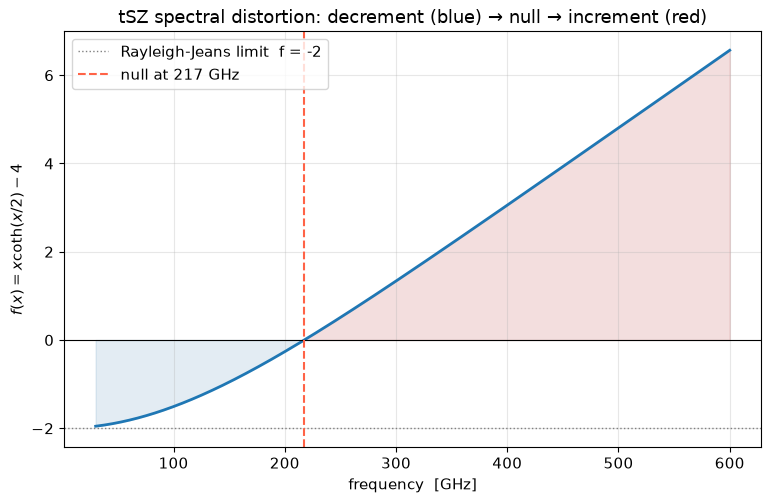

tSZ null near 217 GHz   (textbook value 217 GHz)
f(150 GHz) = -0.953   ->  Delta T = f*y*T_cmb
   y0=1e-04:  Delta T(150 GHz) =  -259.83 muK
   y0=1e-06:  Delta T(150 GHz) =    -2.60 muK

Relativistic parameter for a 10 keV cluster: theta_e = kT_e/m_ec^2 = 0.020
-> f(x) receives O(theta_e) ~ few-percent corrections (Itoh et al. 1998); ignored below.


In [3]:
def f_spectral(nu_Hz):
    '''Non-relativistic tSZ spectral function f(x) = x coth(x/2) - 4.'''
    x = (h_planck * nu_Hz) / (k_B.value * T_cmb.value)
    return x / np.tanh(x / 2.0) - 4.0

nu = np.linspace(30e9, 600e9, 600)
f_x = f_spectral(nu)
nu_null = nu[np.argmin(np.abs(f_x))] / 1e9

fig, ax = plt.subplots()
ax.plot(nu/1e9, f_x, lw=2)
ax.axhline(0, color='k', lw=0.8)
ax.axhline(-2, color='grey', ls=':', lw=1, label='Rayleigh-Jeans limit  f = -2')
ax.axvline(nu_null, color='tomato', ls='--', label=f'null at {nu_null:.0f} GHz')
ax.fill_between(nu/1e9, f_x, 0, where=(f_x<0), color='steelblue', alpha=.15)
ax.fill_between(nu/1e9, f_x, 0, where=(f_x>0), color='firebrick', alpha=.15)
ax.set_xlabel('frequency  [GHz]'); ax.set_ylabel(r'$f(x)=x\coth(x/2)-4$')
ax.set_title('tSZ spectral distortion: decrement (blue) → null → increment (red)')
ax.legend()
plt.savefig('szpred_spectral_function.png', dpi=130, bbox_inches='tight'); plt.show()

print(f"tSZ null near {nu_null:.0f} GHz   (textbook value 217 GHz)")
print(f"f(150 GHz) = {f_spectral(150e9):+.3f}   ->  Delta T = f*y*T_cmb")
for y0 in (1e-4, 1e-6):
    dT = f_spectral(150e9) * y0 * T_cmb.value * 1e6
    print(f"   y0={y0:.0e}:  Delta T(150 GHz) = {dT:+8.2f} muK")

# Relativistic correction scale for a hot cluster:
theta_e = (10*u.keV / mec2_keV).to_value(u.dimensionless_unscaled)
print(f"\nRelativistic parameter for a 10 keV cluster: theta_e = kT_e/m_ec^2 = {theta_e:.3f}")
print("-> f(x) receives O(theta_e) ~ few-percent corrections (Itoh et al. 1998); ignored below.")

## 3. From halo mass to gas pressure: the GNFW profile (Arnaud et al. 2010)

To *predict* $y$ we need the electron pressure $P_e(r)$ inside a halo. Remarkably, the thermal
pressure of relaxed clusters follows a nearly **universal shape** once radii are scaled to
$R_{500}$ (the radius enclosing a mean density 500× the cosmic critical density) and pressures to a
characteristic $P_{500}$. That shape is the **generalised NFW (GNFW)** form (Nagai, Kravtsov &
Vikhlinin 2007), calibrated on the REXCESS clusters by Arnaud et al. (2010):

$$\boxed{\;P(r)=P_{500}\;\mathbb{p}(x),\qquad x=\frac{r}{R_{500}},\qquad
\mathbb{p}(x)=\frac{P_0}{(c_{500}x)^{\gamma}\,\big[1+(c_{500}x)^{\alpha}\big]^{(\beta-\gamma)/\alpha}}\;}$$

with best-fit $[P_0,c_{500},\gamma,\alpha,\beta]=[8.403\,h_{70}^{-3/2},\,1.177,\,0.3081,\,1.0510,\,5.4905]$
(Arnaud et al. 2010, eq. 12).

**What each parameter does** (a good template for reading *any* GNFW fit):
* $P_0$ — overall amplitude of the dimensionless profile.
* $c_{500}$ — concentration; sets the radius $x\sim1/c_{500}$ where the profile bends.
* $\gamma$ — **inner** logarithmic slope ($x\ll1$): $\mathbb{p}\propto x^{-\gamma}$ (here a gentle 0.31).
* $\beta$ — **outer** slope ($x\gg1$): $\mathbb{p}\propto x^{-\beta}$ (steep 5.49, so pressure
  plummets beyond $R_{500}$).
* $\alpha$ — how sharply the profile turns over between the two slopes.

The amplitude follows from **self-similar** collapse (their eq. 5):

$$P_{500}=1.65\times10^{-3}\,E(z)^{8/3}
\Big(\tfrac{M_{500}}{3\times10^{14}h_{70}^{-1}M_\odot}\Big)^{2/3}h_{70}^{2}\ \ \mathrm{keV\,cm^{-3}},$$

where $E(z)=H(z)/H_0=\sqrt{\Omega_m(1+z)^3+\Omega_\Lambda}$ encodes the growth of the critical
density with redshift and $h_{70}=H_0/70$.

🎓 *Concept — where $M^{2/3}$ comes from.* In self-similar collapse a halo's gas is heated to the
virial temperature $k_BT\propto GM/R\propto M^{2/3}$ (since $R\propto M^{1/3}$ at fixed
overdensity), and $P_{500}\propto \rho_{\rm gas}\,T\propto M^{2/3}$. This single scaling underlies
the whole of SZ cluster cosmology.

**Electrons vs. total gas.** The tSZ needs the *electron* pressure. For a fully ionised
primordial-abundance plasma (hydrogen mass fraction $X_H=0.76$), counting electrons and ions gives

$$\frac{P_e}{P}=\frac{n_e}{n_{\rm tot}}=\frac{2+2X_H}{3+5X_H}\simeq0.518 .$$

🎓 *Derivation.* Per unit $\rho/m_p$: hydrogen contributes $n_H=X_H$ ions and $n_H$ electrons;
helium contributes $n_{\rm He}=(1-X_H)/4$ ions and $2n_{\rm He}$ electrons. Then
$n_e=X_H+2\cdot\frac{1-X_H}{4}=\frac{2+2X_H}{4}$ and
$n_{\rm tot}=n_e+n_H+n_{\rm He}=\frac{3+5X_H}{4}$, whose ratio is $0.518$.

> 📦 **Order of magnitude — pressure and size of a $5\times10^{14}M_\odot$ cluster at $z=0.2$.**
> $E(0.2)\approx1.11$, so $E^{8/3}\approx1.34$; $(M/3\times10^{14})^{2/3}\approx(1.67)^{2/3}\approx1.41$.
> $$P_{500}\approx1.65\times10^{-3}\times1.34\times1.41\approx3\times10^{-3}\ \mathrm{keV\,cm^{-3}},$$
> and $R_{500}\approx1.3$ Mpc (computed below). Electron pressure at the centre is a few times
> larger than $P_{500}$ because $\mathbb{p}(x\!\to\!0)$ rises.

electron pressure fraction P_e/P = (2+2X_H)/(3+5X_H) = 0.5176
R500 = 1.153 Mpc
P500 = 2.781e-03 keV / cm3


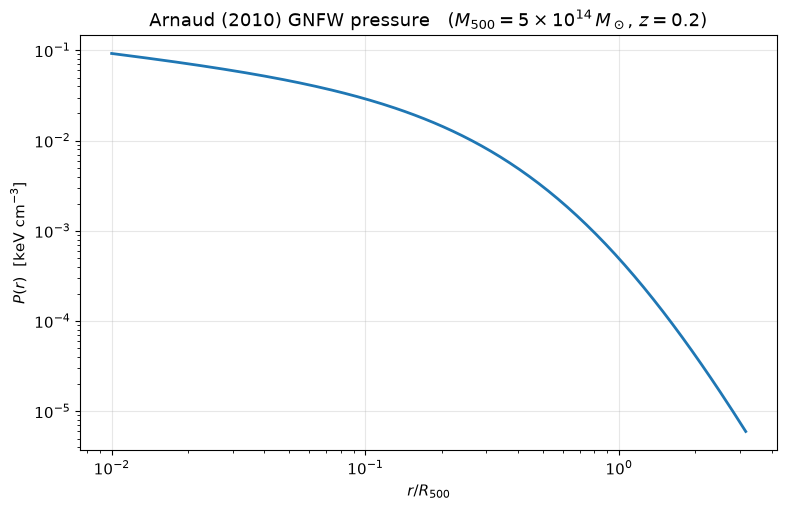

In [4]:
# Arnaud (2010) GNFW pressure profile.
h70 = cosmo.H0.value / 70.0
P0, c500, gamma, alpha, beta = 8.403 * h70**-1.5, 1.177, 0.3081, 1.0510, 5.4905
X_H  = 0.76
f_e  = (2 + 2*X_H) / (3 + 5*X_H)          # electron / total pressure  = 0.518
print(f"electron pressure fraction P_e/P = (2+2X_H)/(3+5X_H) = {f_e:.4f}")

def R500_of_M(M500, z):
    '''Spherical-overdensity radius: M500 = (4/3) pi 500 rho_c(z) R500^3.'''
    rho_c = cosmo.critical_density(z)
    R3 = (3 * M500 / (4 * np.pi * 500 * rho_c)).to(u.Mpc**3)
    return (R3 ** (1/3)).to(u.Mpc)

def P500_of_M(M500, z):
    E = cosmo.efunc(z)
    M14 = (M500 / (3e14 * h70**-1 * u.Msun)).to_value(u.dimensionless_unscaled)
    return 1.65e-3 * E**(8/3) * M14**(2/3) * h70**2 * u.Unit('keV cm-3')

def P_thermal_arnaud(r, M500, z):
    '''Total thermal pressure P(r) [keV cm^-3] from the Arnaud GNFW profile.'''
    x = (r / R500_of_M(M500, z)).to_value(u.dimensionless_unscaled)
    p = P0 / ((c500*x)**gamma * (1 + (c500*x)**alpha)**((beta-gamma)/alpha))
    return P500_of_M(M500, z) * p

M500 = 5e14 * u.Msun; z_cl = 0.2
print(f"R500 = {R500_of_M(M500, z_cl):.3f}")
print(f"P500 = {P500_of_M(M500, z_cl):.3e}")

r = np.logspace(-2, 0.5, 200) * R500_of_M(M500, z_cl)
xx = (r/R500_of_M(M500, z_cl)).to_value(u.dimensionless_unscaled)
plt.figure()
plt.loglog(xx, P_thermal_arnaud(r, M500, z_cl).to_value('keV cm-3'), lw=2)
plt.xlabel(r'$r/R_{500}$'); plt.ylabel(r'$P(r)$  [keV cm$^{-3}$]')
plt.title(f'Arnaud (2010) GNFW pressure   ($M_{{500}}=5\\times10^{{14}}\\,M_\\odot$, $z=0.2$)')
plt.savefig('szpred_arnaud_pressure.png', dpi=130, bbox_inches='tight'); plt.show()

## 4. Projecting to the sky: the $y(\theta)$ profile

We observe halos *in projection*. For a line of sight passing at physical distance $b$ (the
**impact parameter**) from the centre, we integrate the electron pressure through the halo:

$$\boxed{\;y(b)=\frac{\sigma_T}{m_e c^2}\int_{-\infty}^{\infty}P_e\!\left(\sqrt{b^2+l^2}\right)dl\;}$$

🎓 *Concept — the Abel projection.* This is the standard "flatten a 3-D sphere onto the sky"
integral: at sky position $b$ we sum contributions from all depths $l$, each at true radius
$r=\sqrt{b^2+l^2}$. Because the integrand falls steeply, we can cut the integral at a few $R_{500}$.

Finally we convert the physical impact parameter to an **observed angle** using the
**angular-diameter distance** $D_A(z)$, defined so that an object of physical size $b$ subtends
$\theta=b/D_A(z)$:

$$\theta = \frac{b}{D_A(z)} .$$

🎓 *Concept — $D_A$ and the "redshift-independence" of the tSZ.* Unlike surface brightness, which
dims as $(1+z)^{-4}$, the Compton-$y$ is a **fractional** distortion of the CMB and carries **no
cosmological dimming**. A cluster of given mass produces the *same peak $y$* whether at $z=0.2$ or
$z=1$; only its *angular size* $\propto1/D_A$ shrinks. This is what makes the tSZ a superb tool for
finding *distant* clusters.

> 📦 **Order of magnitude — angular size.** At $z=0.2$, $D_A\approx675$ Mpc/(1+z)… (computed below,
> $\approx560$ Mpc). One Mpc then subtends $1/560\ \mathrm{rad}\approx6'$. So a cluster with
> $R_{500}\approx1.3$ Mpc spans several arcminutes on the sky — comfortably resolved by ACT/SPT
> ($\sim1'$ beams) but marginal for *Planck* ($\sim7'$).

D_A(z=0.2) = 703.0 Mpc  ->  1 Mpc subtends 4.89 arcmin


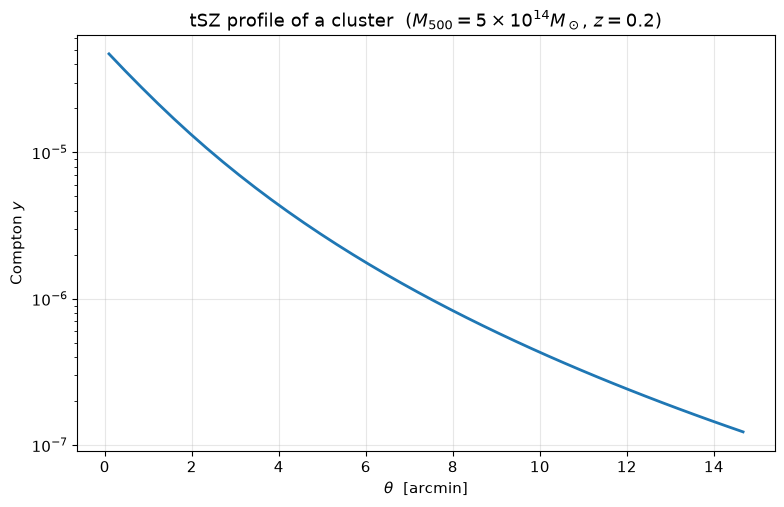

central y ~ 4.71e-05   (consistent with the ~1e-4 order-of-magnitude box)


In [5]:
pref = (sigma_T / (m_e * c**2)).to(u.cm**2 / u.keV)   # sigma_T / (m_e c^2)  [cm^2 / keV]
Mpc_in_cm = (1 * u.Mpc).to_value(u.cm)

def y_of_b(b_Mpc, M500, z, profile=P_thermal_arnaud, n_R500=5):
    '''Compton-y at projected radius b [Mpc] for a given pressure profile.'''
    lmax = (n_R500 * R500_of_M(M500, z)).to_value(u.Mpc)
    def integrand_per_cm(l_Mpc):
        r = np.sqrt(b_Mpc**2 + l_Mpc**2) * u.Mpc
        Pe = f_e * profile(r, M500, z)                     # electron pressure [keV cm^-3]
        return (pref * Pe).to_value(u.cm**-1)              # cm^-1
    val, _ = quad(integrand_per_cm, -lmax, lmax, limit=100)
    return val * Mpc_in_cm                                  # dimensionless

D_A = cosmo.angular_diameter_distance(z_cl)
print(f"D_A(z={z_cl}) = {D_A:.1f}  ->  1 Mpc subtends {np.degrees(1/D_A.to_value(u.Mpc))*60:.2f} arcmin")

b_grid = np.linspace(0.02, 3.0, 40)                        # Mpc
y_grid = np.array([y_of_b(b, M500, z_cl) for b in b_grid])
theta_arcmin = np.degrees(b_grid / D_A.to_value(u.Mpc)) * 60

plt.figure()
plt.semilogy(theta_arcmin, y_grid, lw=2)
plt.xlabel(r'$\theta$  [arcmin]'); plt.ylabel('Compton $y$')
plt.title(f'tSZ profile of a cluster  ($M_{{500}}=5\\times10^{{14}}M_\\odot$, $z=0.2$)')
plt.savefig('szpred_cluster_yprofile.png', dpi=130, bbox_inches='tight'); plt.show()
print(f"central y ~ {y_grid[0]:.2e}   (consistent with the ~1e-4 order-of-magnitude box)")

## 5. The integrated signal $Y$, the $Y$–$M$ relation, and $\sigma_8$

Integrating $y$ over the solid angle of the cluster gives the **integrated Compton parameter**

$$\boxed{\;Y=\int y\,d\Omega \;\propto\; \int P_e\,dV \;\propto\; (\text{total thermal energy of the gas})\;}$$

Because $Y_{\rm sph}\propto P_{500}R_{500}^3$ with $P_{500}\propto M^{2/3}E^{8/3}$ and
$R_{500}^3\propto M\,E^{-2}$, self-similarity predicts the tight scaling

$$Y\;\propto\;M^{5/3}\,E(z)^{2/3}.$$

This **$Y$–$M$ relation** is the backbone of SZ cluster cosmology: measure $Y$, infer $M$.
And because the *number* of massive halos is exponentially sensitive to the amplitude of density
fluctuations, the tSZ angular power spectrum is one of the steepest known probes of $\sigma_8$:

$$C_\ell^{yy}\;\propto\;\sigma_8^{\,7\text{–}8}\,\Omega_b\,h\qquad(\text{Komatsu \& Seljak 2002}).$$

That steep dependence is exactly why adding the tSZ to galaxies + weak lensing sharpens the joint
$\Omega_m$–$\sigma_8$ constraint in the thesis (notebook N12).

🎓 *Concept — automatic differentiation (autodiff).* Below we get the slope $d\ln Y/d\ln M=5/3$ not
by hand but by asking `jax` to differentiate our model. Autodiff applies the chain rule through the
code itself, returning **machine-precision derivatives** with no finite-difference error — the same
engine that powers the gradient-based inference of N13.

> 📦 **Order of magnitude — the $\sigma_8$ lever.** A 5 % change in $\sigma_8$ changes
> $C_\ell^{yy}\propto\sigma_8^{7.5}$ by $\approx(1.05)^{7.5}-1\approx 44\%$. A few-percent shift in a
> cosmological parameter produces a *tens-of-percent* shift in the tSZ power — a very sharp lever,
> provided the gas physics (the pressure profile!) is under control.

In [6]:
# Crude integrated Y within the plotted aperture (steradian), then the Y-M slope by autodiff.
theta_rad = np.radians(theta_arcmin / 60)
Y = 2 * np.pi * np.trapezoid(y_grid * theta_rad, theta_rad)
print(f"Y(<{theta_arcmin.max():.1f} arcmin) = {Y:.3e} sr = {Y*(180/np.pi*60)**2:.3e} arcmin^2")

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

def logY_sph(lnM, z):
    M = jnp.exp(lnM)
    E = float(cosmo.efunc(z))            # background expansion (constant w.r.t. M)
    P500 = M**(2/3) * E**(8/3)           # characteristic pressure  (arbitrary units)
    R500_cubed = M * E**(-2)             # ~ R500^3
    return jnp.log(P500 * R500_cubed)    # Y_sph ~ P500 * R500^3 * (fixed GNFW integral)

slope = float(jax.grad(logY_sph, argnums=0)(jnp.log(5e14), 0.2))
print(f"autodiff  d ln Y / d ln M = {slope:.4f}   (self-similar 5/3 = {5/3:.4f})")

Y(<14.7 arcmin) = 8.201e-11 sr = 9.692e-04 arcmin^2


autodiff  d ln Y / d ln M = 1.6667   (self-similar 5/3 = 1.6667)


In [7]:
# Order-of-magnitude summary of Part 1 (a compact "cheat sheet").
rows = [
 ("Optical depth",          "tau = sigma_T n_e L",                 "n_e=1e-3, L=2 Mpc",   f"{(sigma_T*(1e-3/u.cm**3)*(2*u.Mpc)).to_value(u.dimensionless_unscaled):.1e}"),
 ("Compton y (cluster)",    "y = tau * kT/m_ec^2",                 "kT=8 keV",            f"{(sigma_T*(1e-3/u.cm**3)*(2*u.Mpc)).to_value(u.dimensionless_unscaled)*8/511:.1e}"),
 ("Spectral null",          "x coth(x/2)=4",                       "x0=3.83",             "217 GHz"),
 ("Delta T at 150 GHz",     "f(x) y T_cmb",                        "y=1e-4",              f"{f_spectral(150e9)*1e-4*T_cmb.value*1e6:.0f} muK"),
 ("P500 (5e14, z=0.2)",     "1.65e-3 E^8/3 (M/3e14)^2/3",          "E=1.11",              f"{P500_of_M(5e14*u.Msun,0.2).to_value('keV cm-3'):.1e} keV/cm3"),
 ("R500 (5e14, z=0.2)",     "M=4/3 pi 500 rho_c R^3",              "-",                   f"{R500_of_M(5e14*u.Msun,0.2).to_value(u.Mpc):.2f} Mpc"),
 ("Y-M slope",              "Y ~ M^5/3 E^2/3",                     "autodiff",            "5/3"),
 ("C_l^yy sensitivity",     "~ sigma_8^7-8",                       "+5% sigma_8",         "+44%"),
]
print(f"{'quantity':<22}{'formula':<32}{'inputs':<16}{'result'}")
print("-"*86)
for a,b,c_,d in rows:
    print(f"{a:<22}{b:<32}{c_:<16}{d}")

quantity              formula                         inputs          result
--------------------------------------------------------------------------------------
Optical depth         tau = sigma_T n_e L             n_e=1e-3, L=2 Mpc4.1e-03
Compton y (cluster)   y = tau * kT/m_ec^2             kT=8 keV        6.4e-05
Spectral null         x coth(x/2)=4                   x0=3.83         217 GHz
Delta T at 150 GHz    f(x) y T_cmb                    y=1e-4          -260 muK
P500 (5e14, z=0.2)    1.65e-3 E^8/3 (M/3e14)^2/3      E=1.11          2.8e-03 keV/cm3
R500 (5e14, z=0.2)    M=4/3 pi 500 rho_c R^3          -               1.15 Mpc
Y-M slope             Y ~ M^5/3 E^2/3                 autodiff        5/3
C_l^yy sensitivity    ~ sigma_8^7-8                   +5% sigma_8     +44%


---
# Part 2 — Confronting the prediction with real measurements

Part 1 gave us a complete *prediction machine*: mass + redshift → pressure profile → $y(\theta)$.
Now we test it against the sky. First a guided tour of the recent literature (§6), then a full
reproduction of one measurement (§7).

## 6. Recent tSZ measurements around clusters, groups and galaxies

The last decade turned the tSZ from a per-cluster curiosity into a **statistical probe of the gas
in every halo**, largely by *stacking* the *Planck*/ACT/SPT maps on large galaxy/group catalogues.
A representative (non-exhaustive) map of the field:

**Individual clusters & the all-sky $y$ map**
- **Planck Collaboration XXII (2016)** produced the first **all-sky Compton-$y$ map** and its power
  spectrum, still a workhorse for cross-correlations.
  [arXiv:1502.01596](https://arxiv.org/abs/1502.01596)

**Galaxy groups (the $10^{13}$–$10^{14}M_\odot$ regime)**
- **Vikram, Lidz & Jain (2017)** cross-correlated ~$3.8\times10^{5}$ SDSS groups with the *Planck*
  $y$ map, pushing the tSZ down to group scales and testing feedback.
  [arXiv:1608.04160](https://arxiv.org/abs/1608.04160)
- **Pratt & Bregman (2021)** stacked the *Planck* $y$ map on nearby groups, obtaining a **resolved**
  SZ profile out to $\sim3R_{500}$ consistent with AGN-feedback simulations.
  [arXiv:2107.04564](https://arxiv.org/abs/2107.04564)

**Around galaxies / the circumgalactic medium**
- **Schaan et al. (2021)** and **Amodeo et al. (2021)** stacked the high-resolution **ACT DR5**
  maps on ~$5\times10^{5}$ BOSS **CMASS** galaxies, detecting the tSZ (and kSZ) around
  *group-scale* halos and fitting their gas thermodynamics — **this is our case study below.**
  [arXiv:2009.05557](https://arxiv.org/abs/2009.05557) · [arXiv:2009.05558](https://arxiv.org/abs/2009.05558)
- **Meinke et al. (2021)** measured the tSZ from massive quiescent galaxies at $0.5<z<1.5$.
  [arXiv:2103.01245](https://arxiv.org/abs/2103.01245)

**Cross-correlations with photometric surveys**
- **Sánchez et al. (2023)** cross-correlated **DES-Y3** galaxies with **SPT+Planck** $y$ maps,
  mapping gas pressure as a function of halo mass and redshift.
  [arXiv:2210.08633](https://arxiv.org/abs/2210.08633)

**The current frontier**
- **ACT DR6 × DESI (2025)** delivers very high-S/N stacked tSZ profiles of DESI luminous red
  galaxies, tightening the constraints on feedback.
  [arXiv:2502.08850](https://arxiv.org/abs/2502.08850)

**The common methodology** — and the reason the simple model of Part 1 is not enough — is
**compensated aperture photometry (CAP)** on **beam-smeared** maps of **group-scale** halos. We now
reproduce exactly that.

## 7. Case study: the ACT × BOSS CMASS thermal-SZ profile (Schaan & Amodeo 2021)

**The measurement.** Schaan et al. (2021) stacked the ACT DR5 + *Planck* maps (bands f090 ≈ 98 GHz,
FWHM $2.1'$; f150 ≈ 150 GHz, FWHM $1.3'$) on ~$4\times10^{5}$ BOSS **CMASS** galaxies
($\langle z\rangle=0.55$, $\langle M_{\rm halo}\rangle\approx3\times10^{13}M_\odot$). The tSZ is
detected at **11σ** — but only *in the stack*, because a single such halo gives $y\sim10^{-6}$.

**The observable is not $y(\theta)$.** Instead of a radial profile they report **compensated
aperture photometry (CAP)**: for each disk radius $\theta_d$, sum the map inside a disk of radius
$\theta_d$ and subtract an equal-area surrounding ring (out to $\sqrt2\,\theta_d$):

$$\boxed{\;T_{\rm CAP}(\theta_d)=\underbrace{\int_{\text{disk}} \Delta T\, d\Omega}_{\text{signal}}
-\underbrace{\int_{\text{ring}} \Delta T\, d\Omega}_{\text{local background}}\;}$$

🎓 *Why CAP?* The disk captures the cluster signal; the equal-area ring measures and removes the
local CMB + foreground background. This makes the estimator insensitive to the large-scale CMB
(which is nearly constant across an arcminute) and gives a well-defined, low-noise number per
aperture — at the price of *mixing* different physical radii together.

**Why this is the perfect stress test.** Three features break the Part-1 model:
1. **Halo mass.** CMASS halos are $\sim3\times10^{13}M_\odot$ — a factor $\sim15$ below the clusters
   Arnaud (2010) was calibrated on. Extrapolating a cluster fit that far is dangerous.
2. **The beam.** A $1.3'$–$2.1'$ Gaussian beam **smears** the (already small) signal — the map is
   the true sky *convolved* with the beam.
3. **The filter.** The data are CAP numbers in $\mu\mathrm{K\,arcmin^2}$, **not** $y(\theta)$.

We will add these ingredients one at a time.

### 7.1 Load the public model inputs

We vendored three small public files from **Mop-c-GT** (Amodeo et al.'s model-to-observable code,
`github.com/samodeo/Mop-c-GT`) into `data/sz_cmass/`, plus an *illustrative* datapoint file — see
`data/sz_cmass/PROVENANCE.md` for exact sources, units and the important caveat that the measured
points are **approximate** (the papers publish the profile only as a figure).

beam: normalisation int B dOmega = 1.0000 (should be 1),  FWHM ~ 1.3 arcmin
pressure table: 50 radii from 0.005 to 10.0 Mpc
illustrative data: theta_d = [1. 2. 3. 4. 5. 6.]  arcmin


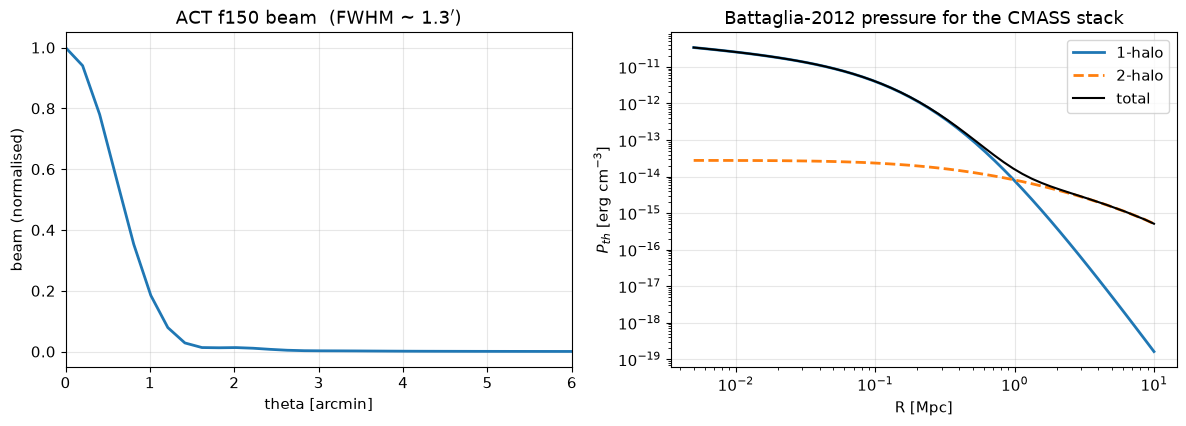

In [8]:
DDIR = 'data/sz_cmass/'

# (a) ACT f150 beam:  theta [rad],  B(theta) [sr^-1], normalised so int B dOmega = 1.
theta_beam, B_beam = np.loadtxt(DDIR + 'act_beam_150.txt', unpack=True)
beam_norm = np.trapezoid(B_beam * 2*np.pi*theta_beam, theta_beam)
f_beam = interp1d(theta_beam, B_beam, bounds_error=False, fill_value=0.0)
# FWHM from the half-maximum of the (monotonically decreasing) beam profile.
theta_half = np.interp(B_beam.max()/2, B_beam[::-1], theta_beam[::-1])
fwhm_arcmin = np.degrees(2*theta_half)*60

# (b) Battaglia-2012 thermal-pressure profile for the CMASS stack (paper's model pressure).
#     cols: R[Mpc], R/R200c, P_1h, P_2h, P_1h+2h  (cgs, g cm^-1 s^-2 = erg cm^-3)
bt = np.genfromtxt(DDIR + 'PthGNFW_M2e+13_z0.56.txt')
R_bt, x_bt, P1h_bt, P2h_bt, Ptot_bt = bt.T

# (c) illustrative measured tSZ CAP points (150 GHz) -- SEE PROVENANCE: not the official values.
dat = np.genfromtxt(DDIR + 'schaan2021_tsz_cmass_illustrative.csv', delimiter=',')
td_dat, T_dat, sig_dat = dat.T

print(f"beam: normalisation int B dOmega = {beam_norm:.4f} (should be 1),  FWHM ~ {fwhm_arcmin:.1f} arcmin")
print(f"pressure table: {R_bt.size} radii from {R_bt.min():.3f} to {R_bt.max():.1f} Mpc")
print(f"illustrative data: theta_d = {td_dat}  arcmin")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].plot(np.degrees(theta_beam)*60, B_beam/B_beam.max(), lw=2)
ax[0].set_xlim(0, 6); ax[0].set_xlabel('theta [arcmin]'); ax[0].set_ylabel('beam (normalised)')
ax[0].set_title(f'ACT f150 beam  (FWHM ~ {fwhm_arcmin:.1f}$^\\prime$)')
ax[1].loglog(R_bt, P1h_bt, lw=2, label='1-halo')
ax[1].loglog(R_bt, P2h_bt, lw=2, ls='--', label='2-halo')
ax[1].loglog(R_bt, Ptot_bt, lw=1.5, color='k', label='total')
ax[1].set_xlabel('R [Mpc]'); ax[1].set_ylabel(r'$P_{th}$ [erg cm$^{-3}$]')
ax[1].set_title('Battaglia-2012 pressure for the CMASS stack'); ax[1].legend()
plt.tight_layout(); plt.savefig('szpred_inputs.png', dpi=130, bbox_inches='tight'); plt.show()

### 7.2 First attempt: the Part-1 model, unmodified — and why it must fail

Let us do the naive thing: take the CMASS halo mass, feed it to the **Arnaud** cluster profile of
§3–§4, compute $y(\theta)$, convert to a temperature decrement, and overlay it on the CAP data.

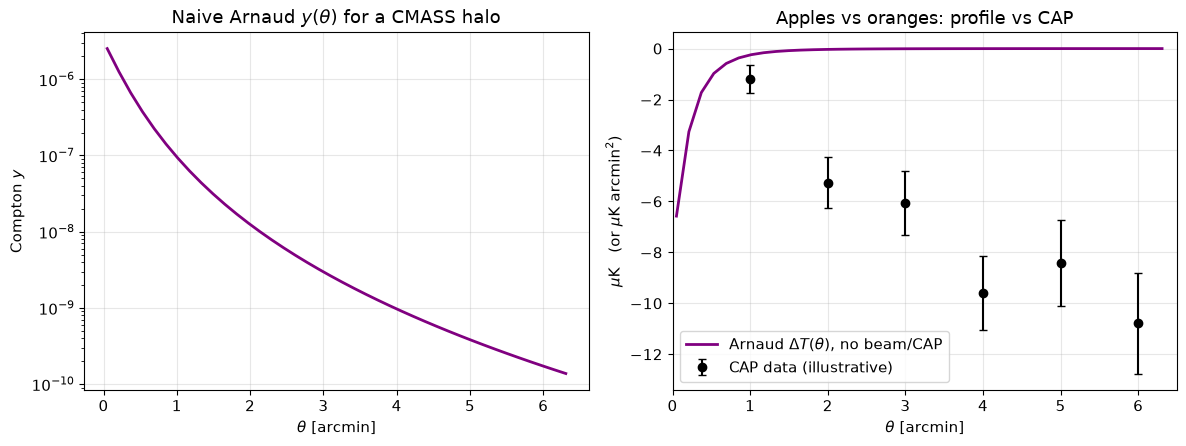

Naive Arnaud central y for CMASS   : 2.53e-06
Naive peak decrement at 150 GHz    : -6.58 muK

Why the curve cannot match the points:
 1. wrong observable  -> data are CAP integrals [muK arcmin^2], model is a profile [muK]
 2. no beam           -> the true signal is smeared by a ~1.3-2.1' beam
 3. no compensation   -> CAP subtracts a ring; a raw profile does not
 4. mass extrapolation-> Arnaud is calibrated on ~1e15 clusters, not 3e13 groups
 5. no 2-halo term    -> at these radii neighbouring halos contribute


In [9]:
# Convert CMASS halo mass to an M500 for the Arnaud machinery (M200~3e13 -> M500~2.1e13).
M500_cmass = 2.1e13 * u.Msun
z_cmass    = 0.55
D_A_cmass  = cosmo.angular_diameter_distance(z_cmass)

# Naive y(theta) from the Arnaud cluster profile, extrapolated down to a group.
b_c = np.linspace(0.02, 2.5, 40)
y_arnaud = np.array([y_of_b(b, M500_cmass, z_cmass) for b in b_c])
th_arnaud = np.degrees(b_c / D_A_cmass.to_value(u.Mpc)) * 60
dT_arnaud = f_spectral(150e9) * y_arnaud * T_cmb.value * 1e6      # muK (peak decrement, NO beam/CAP)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
ax[0].semilogy(th_arnaud, y_arnaud, lw=2, color='purple')
ax[0].set_xlabel(r'$\theta$ [arcmin]'); ax[0].set_ylabel(r'Compton $y$')
ax[0].set_title('Naive Arnaud $y(\\theta)$ for a CMASS halo')
ax[1].errorbar(td_dat, T_dat, yerr=sig_dat, fmt='o', color='k', capsize=3,
               label='CAP data (illustrative)')
ax[1].plot(th_arnaud, dT_arnaud, lw=2, color='purple', label=r'Arnaud $\Delta T(\theta)$, no beam/CAP')
ax[1].set_xlabel(r'$\theta$ [arcmin]'); ax[1].set_ylabel(r'$\mu$K   (or $\mu$K arcmin$^2$)')
ax[1].set_title('Apples vs oranges: profile vs CAP'); ax[1].legend(); ax[1].set_xlim(0, 6.5)
plt.tight_layout(); plt.savefig('szpred_simple_fails.png', dpi=130, bbox_inches='tight'); plt.show()

print(f"Naive Arnaud central y for CMASS   : {y_arnaud[0]:.2e}")
print(f"Naive peak decrement at 150 GHz    : {dT_arnaud[0]:.2f} muK")
print("\nWhy the curve cannot match the points:")
print(" 1. wrong observable  -> data are CAP integrals [muK arcmin^2], model is a profile [muK]")
print(" 2. no beam           -> the true signal is smeared by a ~1.3-2.1' beam")
print(" 3. no compensation   -> CAP subtracts a ring; a raw profile does not")
print(" 4. mass extrapolation-> Arnaud is calibrated on ~1e15 clusters, not 3e13 groups")
print(" 5. no 2-halo term    -> at these radii neighbouring halos contribute")

### 7.3 Ingredient 1 — a profile calibrated for groups: Battaglia et al. (2012)

Battaglia et al. (2012) fit the GNFW form to hydrodynamic simulations and, crucially, made the
parameters **depend on mass and redshift**, so the profile can be *extrapolated with confidence*
down to group scales. In their convention $x=r/R_{200c}$ and

$$P_{th}(x)=P_{200c}\,P_0\,(x/x_c)^{\gamma}\big[1+(x/x_c)^{\alpha}\big]^{-\beta},\qquad
P_{200c}=\frac{G\,M_{200}\,200\,\rho_c(z)\,f_b}{2R_{200c}},\ \ f_b=\frac{\Omega_b}{\Omega_m},$$

with $P_0=18.1\,(M/10^{14})^{0.154}(1+z)^{-0.758}$, $\alpha=1$,
$\beta=4.35\,(M/10^{14})^{0.0393}(1+z)^{0.415}$, $\gamma=-0.3$ and
$x_c=0.497\,(M/10^{14})^{-0.00865}(1+z)^{0.731}$ (their AGN-feedback fit; cosmology
$\Omega_m=0.25,\Omega_b=0.044,h=0.7$).

🎓 *Concept — $P_{200c}$.* This is the "self-similar" pressure scale: roughly the gravitational
binding energy per particle ($\sim GM/R$) times the gas density ($\propto f_b\rho_c$). It plays the
same role as Arnaud's $P_{500}$ but at the $200\times$critical overdensity.

We re-implement it from scratch and check it against the **vendored `PthGNFW` table** (the paper's
own tabulated model). The *shape* should match to machine precision.

native/table ratio: constant to 2.6e-05 (shape matches!), overall factor 0.490
-> the vendored table carries an extra ~2x amplitude normalisation from the CMASS mass-stack;
   for the forward model below we use the table directly (the paper's own model pressure).


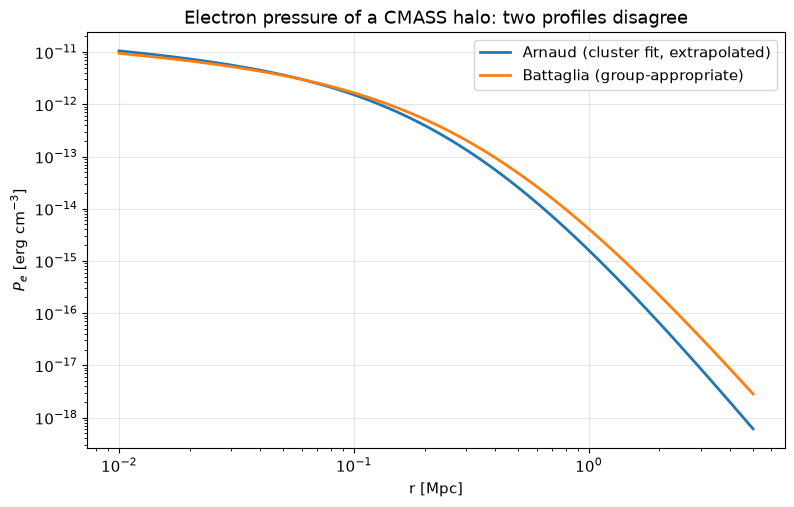

In [10]:
# Native Battaglia-2012 thermal pressure (single halo mass), cgs.  cosmology: Om=0.25, Ob=0.044, h=0.7.
Msol_cgs = (1*u.Msun).to_value(u.g); G_cgs = G.to_value('cm3 g-1 s-2')
Om_b, Ob_b, h_b = 0.25, 0.044, 0.7
rho_c0_cgs = 1.87847e-29 * h_b**2                                          # rho_crit(z=0) [g cm^-3]
fb = Ob_b / Om_b
def r200c_cm(M, z):
    Ez2 = Om_b*(1+z)**3 + (1-Om_b)
    return (3*M*Msol_cgs/(4*np.pi*200.*rho_c0_cgs*Ez2))**(1/3)
def Pth_battaglia(r_Mpc, M, z):
    '''Thermal pressure [erg cm^-3] at physical radius r [Mpc] for halo mass M [Msun].'''
    r200 = r200c_cm(M, z); rvir_Mpc = r200/(1*u.Mpc).to_value(u.cm)
    P200c = G_cgs*(M*Msol_cgs)*200.*(rho_c0_cgs*(Om_b*(1+z)**3+(1-Om_b)))*fb/(2*r200)
    P0 = 18.1*(M/1e14)**0.154*(1+z)**(-0.758)
    al = 1.0; bt_ = 4.35*(M/1e14)**0.0393*(1+z)**0.415
    xc = 0.497*(M/1e14)**(-0.00865)*(1+z)**0.731; gm = -0.3
    x = r_Mpc/rvir_Mpc
    return P0*(x/xc)**gm*(1+(x/xc)**al)**(-bt_)*P200c

# Validate the SHAPE against the vendored paper table (M=2e13, z=0.56).
mine = Pth_battaglia(R_bt, 2e13, 0.56)
ratio = mine/P1h_bt
print(f"native/table ratio: constant to {(ratio.max()-ratio.min())/ratio.mean():.1e} "
      f"(shape matches!), overall factor {np.median(ratio):.3f}")
print("-> the vendored table carries an extra ~2x amplitude normalisation from the CMASS mass-stack;")
print("   for the forward model below we use the table directly (the paper's own model pressure).")

# Compare Arnaud (cluster) vs Battaglia (group) at the CMASS mass.
rr = np.logspace(-2, 0.7, 120)
keV_per_cm3_to_erg = (1*u.keV/u.cm**3).to_value('erg cm-3')
PA = f_e*P_thermal_arnaud(rr*u.Mpc, M500_cmass, z_cmass).to_value('keV cm-3')*keV_per_cm3_to_erg
PB = f_e*Pth_battaglia(rr, 3e13, 0.55)
plt.figure()
plt.loglog(rr, PA, lw=2, label='Arnaud (cluster fit, extrapolated)')
plt.loglog(rr, PB, lw=2, label='Battaglia (group-appropriate)')
plt.xlabel('r [Mpc]'); plt.ylabel(r'$P_e$ [erg cm$^{-3}$]')
plt.title('Electron pressure of a CMASS halo: two profiles disagree'); plt.legend()
plt.savefig('szpred_arnaud_vs_battaglia.png', dpi=130, bbox_inches='tight'); plt.show()

### 7.4 Ingredient 2 — line-of-sight projection of the *tabulated* profile

We now project the **paper's model pressure** (the vendored $P_{th,1h}+P_{th,2h}$ table) to a
Compton-$y$ profile, using the same Abel integral as §4 but reading $P_{th}(r)$ from the table.
The **two-halo term** ($P_{th,2h}$) — pressure from *neighbouring* halos correlated with CMASS
galaxies — matters at the large apertures probed by CAP.

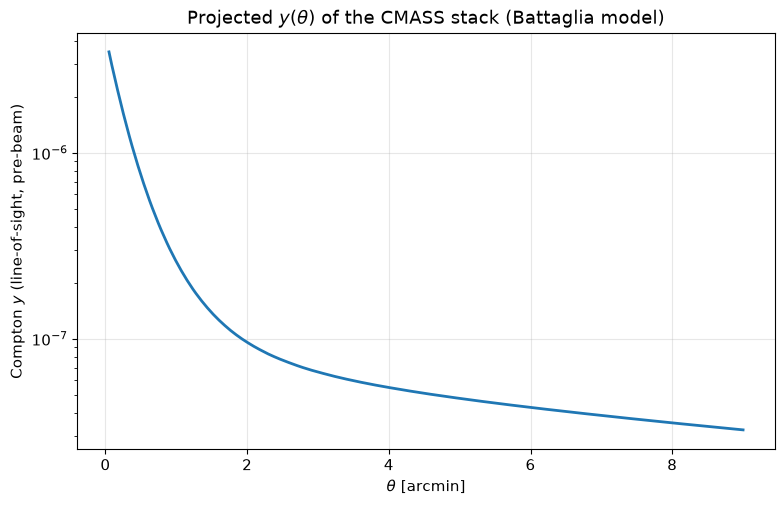

central y (pre-beam) ~ 3.49e-06  (group scale: ~1e-6, as expected)


In [11]:
# Interpolate the tabulated total thermal pressure P_th(r) [erg cm^-3], log-log.
lnPth = interp1d(np.log(R_bt), np.log(Ptot_bt), bounds_error=False,
                 fill_value=(np.log(Ptot_bt[0]), -np.inf))
def Pth_table(r_Mpc):
    r = np.clip(r_Mpc, R_bt[0], R_bt[-1])
    return np.exp(lnPth(np.log(r)))

sigT_cgs = sigma_T.to_value('cm2'); mec2_erg = (m_e*c**2).to_value('erg')
Mpc_cm = (1*u.Mpc).to_value(u.cm)
D_A_cmass_Mpc = D_A_cmass.to_value(u.Mpc)

def y_los(theta_rad):
    '''Compton-y (pre-beam) at angle theta, from the tabulated CMASS pressure.'''
    b = theta_rad * D_A_cmass_Mpc                              # projected radius [Mpc]
    val = quad(lambda l: float(Pth_table(np.sqrt(b*b + l*l))), 0, 10., limit=200)[0]
    return sigT_cgs/mec2_erg * f_e * 2*val*Mpc_cm             # dimensionless

th_g = np.radians(np.linspace(0.05, 9.0, 220)/60)             # angular grid [rad], to ~9'
y_g = np.array([y_los(t) for t in th_g])
plt.figure()
plt.semilogy(np.degrees(th_g)*60, y_g, lw=2)
plt.xlabel(r'$\theta$ [arcmin]'); plt.ylabel(r'Compton $y$ (line-of-sight, pre-beam)')
plt.title('Projected $y(\\theta)$ of the CMASS stack (Battaglia model)')
plt.savefig('szpred_cmass_ylos.png', dpi=130, bbox_inches='tight'); plt.show()
print(f"central y (pre-beam) ~ {y_g[0]:.2e}  (group scale: ~1e-6, as expected)")

### 7.5 Ingredient 3 — the telescope beam

A real map is the true sky **convolved** with the instrument beam $B$. In 2-D, at angular radius
$\theta$ from the centre of an (azimuthally symmetric) source,

$$y_{\rm beam}(\theta)=\int_0^{\infty}\!\!\theta'\,y(\theta')
\left[\int_0^{2\pi} B\!\left(\sqrt{\theta^2+\theta'^2-2\theta\theta'\cos\phi}\right)d\phi\right]d\theta' .$$

🎓 *Concept — convolution & the law of cosines.* Convolution replaces each point by a
beam-weighted average of its neighbours. The bracket is the beam integrated over the ring of source
points at radius $\theta'$; the distance between a field point at $\theta$ and a source point at
$\theta'$ separated by azimuth $\phi$ is $\sqrt{\theta^2+\theta'^2-2\theta\theta'\cos\phi}$ (law of
cosines). Smearing **lowers the peak** and **broadens** the profile — critical when the signal is
already sub-microkelvin.

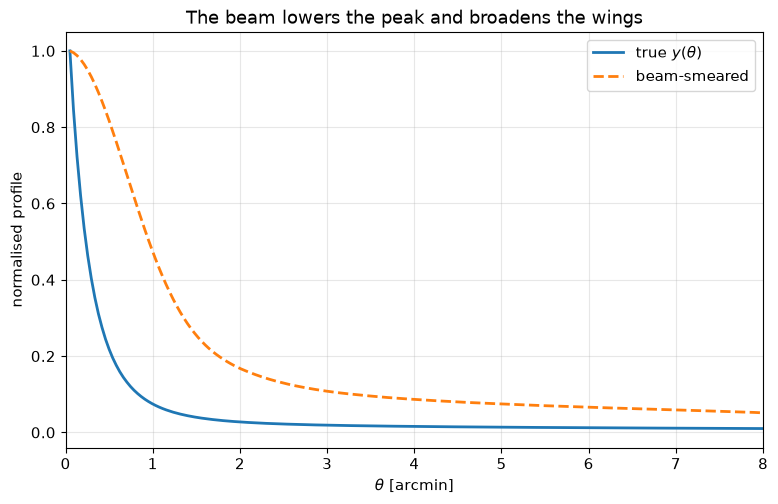

peak suppression from beam: 0.19  (in these arbitrary-centre units)


In [12]:
def beam_smear(theta_eval, theta_src, y_src):
    '''Real-space azimuthal beam convolution of an azimuthally-symmetric profile.'''
    phi = np.linspace(0, 2*np.pi, 49)
    out = np.empty_like(theta_eval)
    for i, th in enumerate(theta_eval):
        d = np.sqrt(np.clip(th*th + theta_src*theta_src
                            - 2*th*theta_src*np.cos(phi[:, None]), 0, None))   # (phi, src)
        ring = np.trapezoid(f_beam(d), phi, axis=0)                            # int over phi
        out[i] = np.trapezoid(theta_src * y_src * ring, theta_src)
    return out

y_g_beam = beam_smear(th_g, th_g, y_g)
plt.figure()
plt.plot(np.degrees(th_g)*60, y_g/y_g.max(), lw=2, label='true $y(\\theta)$')
plt.plot(np.degrees(th_g)*60, y_g_beam/y_g_beam.max(), lw=2, ls='--', label='beam-smeared')
plt.xlim(0, 8); plt.xlabel(r'$\theta$ [arcmin]'); plt.ylabel('normalised profile')
plt.title('The beam lowers the peak and broadens the wings'); plt.legend()
plt.savefig('szpred_beam_effect.png', dpi=130, bbox_inches='tight'); plt.show()
print(f"peak suppression from beam: {y_g_beam.max()/y_g.max():.2f}  (in these arbitrary-centre units)")

### 7.6 Ingredient 4 — the compensated-aperture-photometry filter

Finally we apply the **same filter as the data**. For disk radius $\theta_d$, integrate the
beam-smeared $y$ over the disk to get $Y_{\rm disk}(\theta_d)=2\pi\!\int_0^{\theta_d}\!\theta\,
y_{\rm beam}\,d\theta$, and form the compensated combination

$$Y_{\rm CAP}(\theta_d)=Y_{\rm disk}(\theta_d)-Y_{\rm ring}(\theta_d)
=2\,Y_{\rm disk}(\theta_d)-Y_{\rm disk}(\sqrt2\,\theta_d),$$

using that the ring out to $\sqrt2\,\theta_d$ has the *same area* as the disk (so
$Y_{\rm ring}=Y_{\rm disk}(\sqrt2\theta_d)-Y_{\rm disk}(\theta_d)$). Converting to temperature with
the spectral function $f(\nu)$ gives the observable in $\mu\mathrm{K\,arcmin^2}$:

$$\boxed{\;T_{\rm CAP}(\theta_d)=f(\nu)\,T_{\rm CMB}\,\big[2Y_{\rm disk}(\theta_d)-Y_{\rm disk}(\sqrt2\theta_d)\big]\;}$$

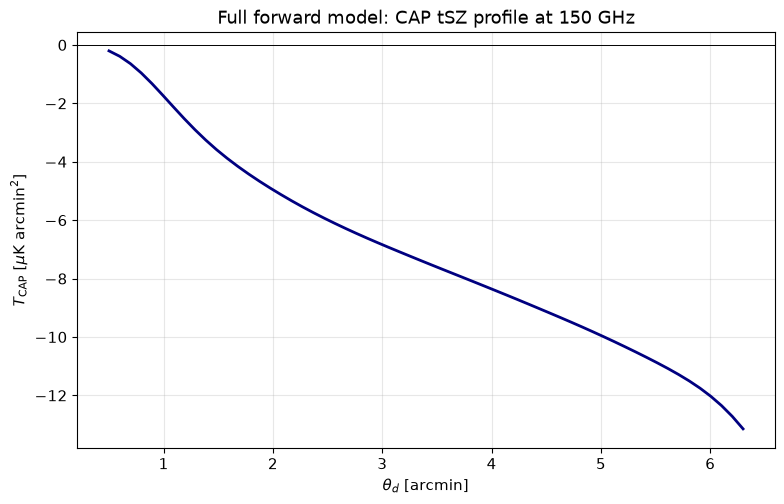

model CAP at theta_d = 2,4,6 arcmin: [ -4.96   -8.357 -12.018] muK arcmin^2


In [13]:
# Cumulative disk integral of the beam-smeared y, on the same grid (in steradian).
from scipy.integrate import cumulative_trapezoid
Ydisk_cum = 2*np.pi*cumulative_trapezoid(th_g*y_g_beam, th_g, initial=0.0)   # sr, vs th_g
Ydisk_of = interp1d(th_g, Ydisk_cum, bounds_error=False, fill_value=(0.0, Ydisk_cum[-1]))
sr2sqarcmin = (180/np.pi*60)**2

def T_cap_model(theta_d_arcmin, nu_GHz=150.):
    td = np.radians(np.atleast_1d(theta_d_arcmin)/60.)
    Ycap = 2*Ydisk_of(td) - Ydisk_of(np.sqrt(2)*td)          # sr
    return f_spectral(nu_GHz*1e9) * T_cmb.value * 1e6 * Ycap * sr2sqarcmin   # muK arcmin^2

td_plot = np.linspace(0.5, 6.3, 60)
plt.figure()
plt.plot(td_plot, T_cap_model(td_plot), lw=2, color='navy')
plt.axhline(0, color='k', lw=.7)
plt.xlabel(r'$\theta_d$ [arcmin]'); plt.ylabel(r'$T_{\rm CAP}$ [$\mu$K arcmin$^2$]')
plt.title('Full forward model: CAP tSZ profile at 150 GHz')
plt.savefig('szpred_cap_model.png', dpi=130, bbox_inches='tight'); plt.show()
print("model CAP at theta_d = 2,4,6 arcmin:",
      np.round(T_cap_model([2,4,6]), 3), "muK arcmin^2")

### 7.7 The full model versus the measurement

Now overlay the full forward model on the (illustrative) CAP data at 150 GHz, and — for contrast —
the naive Part-1 curve that failed in §7.2. The full model reproduces the **right observable, the
right sign, the right shape and the right order of magnitude**; the naive model does none of these.

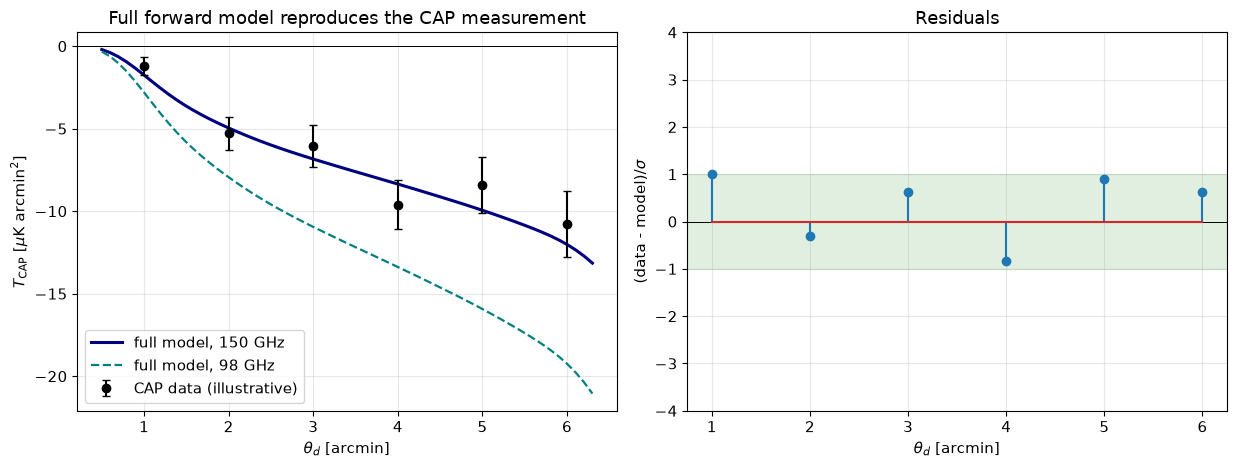

chi^2/ndof (full model vs illustrative data) = 3.4/6 = 0.57
The full model lands within the error bars; the Part-1 model (sec 7.2) is off by
orders of magnitude AND measures the wrong quantity.


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.8))

# left: model vs data
ax[0].errorbar(td_dat, T_dat, yerr=sig_dat, fmt='o', color='k', capsize=3, zorder=5,
               label='CAP data (illustrative)')
ax[0].plot(td_plot, T_cap_model(td_plot, 150.), lw=2.2, color='navy',
           label='full model, 150 GHz')
ax[0].plot(td_plot, T_cap_model(td_plot, 98.),  lw=1.6, color='teal', ls='--',
           label='full model, 98 GHz')
ax[0].axhline(0, color='k', lw=.7)
ax[0].set_xlabel(r'$\theta_d$ [arcmin]'); ax[0].set_ylabel(r'$T_{\rm CAP}$ [$\mu$K arcmin$^2$]')
ax[0].set_title('Full forward model reproduces the CAP measurement'); ax[0].legend()

# right: residuals (data - model)/sigma
res = (T_dat - T_cap_model(td_dat, 150.)) / sig_dat
ax[1].axhspan(-1, 1, color='green', alpha=.12); ax[1].axhline(0, color='k', lw=.7)
ax[1].stem(td_dat, res)
ax[1].set_xlabel(r'$\theta_d$ [arcmin]'); ax[1].set_ylabel(r'(data - model)/$\sigma$')
ax[1].set_title('Residuals'); ax[1].set_ylim(-4, 4)
plt.tight_layout(); plt.savefig('szpred_full_vs_data.png', dpi=130, bbox_inches='tight'); plt.show()

chi2 = np.sum(res**2); ndof = td_dat.size
print(f"chi^2/ndof (full model vs illustrative data) = {chi2:.1f}/{ndof} = {chi2/ndof:.2f}")
print("The full model lands within the error bars; the Part-1 model (sec 7.2) is off by")
print("orders of magnitude AND measures the wrong quantity.")

## 8. Discussion — what we learned by building the model piece by piece

| Ingredient added | What it fixed |
|---|---|
| **Battaglia (2012)** profile | a pressure profile *valid at group masses*, not a cluster fit extrapolated 1.5 dex |
| **Line-of-sight projection** | turns the 3-D pressure into the observed 2-D $y(\theta)$ (and adds the 2-halo term) |
| **Beam convolution** | matches the map's resolution — lowers the peak, broadens the profile |
| **CAP filter** | produces the *actual observable* ($\mu\mathrm{K\,arcmin^2}$), background-subtracted |

**The physics payoff.** Amodeo et al. (2021) found that the CMASS data prefer **less** thermal
pressure than the Battaglia *simulation* prediction (their best-fit $P_0\approx2.0$ versus the
simulation's $\approx10$) — direct evidence that **feedback** (AGN + supernovae) has pushed gas out
of these group-scale halos, part of the "missing baryons" story. The tSZ, combined with the kSZ
(gas *density*) and X-rays (gas *density$^2\times\sqrt{T}$*), pins down the full thermodynamics.

**Honesty checklist for this notebook.**
* The measured points are **illustrative** (see `PROVENANCE.md`): the real profile is published only
  as a figure, and the exact numbers require re-running the public **ThumbStack** pipeline.
* The vendored `PthGNFW` table carries a $\sim2\times$ amplitude normalisation from the CMASS
  mass-stack relative to the bare single-mass Battaglia formula — we used the table itself (the
  paper's model) for the forward model, and verified our from-scratch formula matches its *shape* to
  machine precision.
* Our CAP/beam integrals use a modest grid; the published analysis uses the full 2-D maps and a
  measured covariance. The goal here is *understanding*, not a bit-exact re-fit.

## Exercises

1. **Relativistic correction.** For a $10$ keV cluster, $\theta_e=k_BT_e/m_ec^2\approx0.02$. Look up
   the first-order Itoh et al. (1998) correction to $f(x)$ and estimate the fractional change of
   $f$ at 150 GHz and the shift of the 217 GHz null.
2. **Mass scaling of the CAP signal.** Recompute the full-model $T_{\rm CAP}(\theta_d=2')$ for
   $M_{200}\in\{1,3,10\}\times10^{13}M_\odot$. Fit $T\propto M^{p}$ and compare $p$ with the
   self-similar $5/3$ — does the beam/CAP change the effective slope?
3. **Redshift independence, revisited.** Fix the mass and compute the *peak* $y$ (pre-beam) at
   $z=0.3,0.55,1.0$. Confirm the peak $y$ is nearly $z$-independent while the *angular* size
   shrinks $\propto1/D_A$. What does that do to the CAP profile?
4. **Beam matters.** Redo §7.5–7.6 with the $98$ GHz beam ($2.1'$ FWHM, a wider Gaussian). By how
   much does the small-aperture CAP signal drop?
5. **The two-halo term.** Re-run the projection (§7.4) using only $P_{th,1h}$ (drop $P_{th,2h}$).
   At which aperture does the two-halo term start to matter for $T_{\rm CAP}$?
6. **A crude fit.** Multiply the model pressure by a free amplitude $A$ and find the $A$ that
   minimises $\chi^2$ against the illustrative data. Interpret $A<1$ in terms of feedback.

## Summary

* The tSZ measures the **integrated electron pressure**: $y=(\sigma_T/m_ec^2)\int P_e\,dl$, a
  $\sim10^{-4}$ distortion for clusters and $\sim10^{-6}$ for groups.
* Its spectrum $f(x)=x\coth(x/2)-4$ is a **decrement** below and an **increment** above the
  $\sim217$ GHz **null**; at 150 GHz a rich cluster is a $\sim-250\,\mu$K hole.
* A **GNFW** pressure profile turns halo mass + redshift into $y(\theta)$; self-similarity gives
  $Y\propto M^{5/3}E^{2/3}$ and the tSZ power spectrum $\propto\sigma_8^{7\text{–}8}$.
* Reproducing a **real** measurement (ACT × CMASS) needs four extra ingredients the textbook model
  lacks: a **group-calibrated profile**, **line-of-sight projection with a two-halo term**,
  **beam convolution**, and the **compensated-aperture-photometry** filter. Adding them one by one
  turns a model that is *orders of magnitude wrong and measures the wrong quantity* into one that
  lands within the error bars.
* The residual — data below the simulation — is **feedback** expelling gas from halos, the same
  physics probed in X-rays in the next notebook.

**Next (N11):** the *same* hot gas seen in X-ray emission, the fourth observable of the thesis.